# Advanced radiation and remote sensing


Manfred Brath, Oliver Lemke

## Exercise 2: line shape

In [1]:
%matplotlib widget

import os
import matplotlib.pyplot as plt
import numpy as np
from lineshape import tag2tex, calculate_absxsec, linewidth

# make plot folder, if it is not existing
os.makedirs("plots", exist_ok=True)

cache = None  

The `calculate_absxsec` function calculates absorption cross sections and uses several keyword arguments as inputs, among other lineshape and normalization, see also the function definition in `absorption_module.py` or the contextual help. Please use "VP" (Voigt-Function) as line shape and "VVH"  (van Vleck-Huber) as normalization.

### 1) Absorption cross section and coefficient
Choose an individual line of for example water vapor and perform calculations over a restricted frequency range for a number of different pressures. Keep the temperature constant.

* How does the shape of the spectral lines change?

By now we investigated absorption in terms of the absorption cross-section
$\sigma$. Another widely used unit is the absorption coeffiction
$\alpha$. It takes the number concentration $n$ of the absorber
into account:
$$ \alpha=n\cdot\sigma $$

* How does the absorption coefficient in the line centre change, if pressure is changed?


In [2]:
# Define parameters
species = "H2O"
temperature = 300
pressure = 101325

# Call ARTS to calculate absorption cross sections
freq, abs_xsec, cache = calculate_absxsec(species, pressure, temperature, ws=cache)

Text(0.5, 1.0, 'H$_{2}$O p:1013.25 hPa T:300 K')

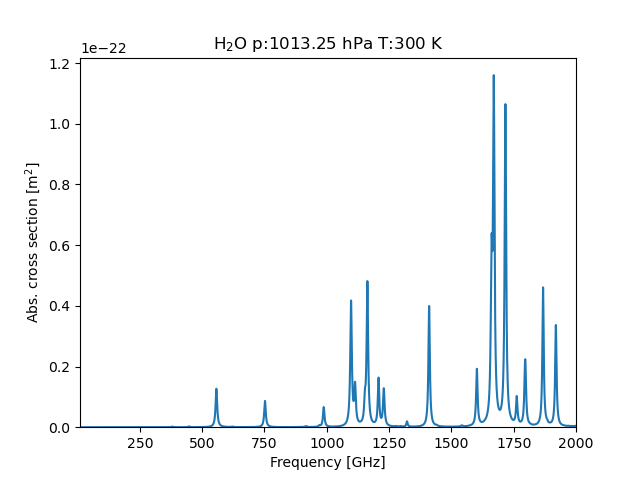

In [3]:
# example plotting code

fig, ax = plt.subplots()
ax.plot(freq / 1e9, abs_xsec)
ax.set_xlim(freq.min() / 1e9, freq.max() / 1e9)
ax.set_ylim(bottom=0)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"Abs. cross section [$\sf m^2$]")
ax.set_title(f"{tag2tex(species)} p:{pressure/100} hPa T:{temperature:0.0f} K")

#uncomment to save the figure
# fig.savefig(  # Save figure.
#     f"plots/plot_xsec_{species}_{pressure:.0f}Pa_{temperature:.0f}K.pdf"
# )

In [4]:
# Define parameters
species = "H2O"
temperature = 300
pressure = 10132.5

# Call ARTS to calculate absorption cross sections
freq, abs_xsec, cache = calculate_absxsec(species, pressure, temperature, ws=cache)

Text(0.5, 1.0, 'H$_{2}$O p:101.325 hPa T:300 K')

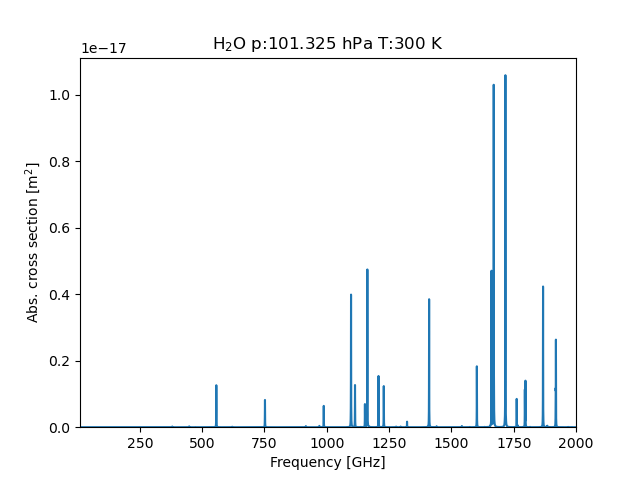

In [5]:
# example plotting code

fig, ax = plt.subplots()
ax.plot(freq / 1e9, abs_xsec*pressure)
ax.set_xlim(freq.min() / 1e9, freq.max() / 1e9)
ax.set_ylim(bottom=0)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"Abs. cross section [$\sf m^2$]")
ax.set_title(f"{tag2tex(species)} p:{pressure/100} hPa T:{temperature:0.0f} K")

#uncomment to save the figure
# fig.savefig(  # Save figure.
#     f"plots/plot_xsec_{species}_{pressure:.0f}Pa_{temperature:.0f}K.pdf"
# )

### 2) Linewidth
The full-width at half maximum (FWHM) is a measure of the line width. Use the function `linewidth()` to calculate the FWHM for a given absorption spectrum.

* Make a plot of this as a function of altitude (pressure) for a microwave line and an infrared absorption line.
